[ENG]

PROJECT 3 : PETROL CONSUMPTION - REGRESSION TREE, RMSE AND CROSS VALIDATION

[FR]

PROJET 3 : CONSOMMATION D'ESSENCE - ARBRE DE REGRESSION, RMSE AND VALIDATION CROISEE

[ENG]

EXERCISE 1: REGRESSION TREE AND RMSE

[FR]

EXERCICE 1 : ARBRE DE REGRESSION ET RMSE

In [57]:
# Packages
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import root_mean_squared_error as RMSE

In [58]:
# Open CSV file
autompg_df= pd.read_csv("C://Users//emmhu//OneDrive//Documents//E-LEARNING//DU DATA ANALYST//4_Introduction au ML supervisé//Données//Project_3_Petrol-consumption//auto-mpg.csv", sep=",")

autompg_df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [59]:
# Observing data structure
autompg_df.shape

(398, 9)

In [60]:
print(autompg_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None


In [61]:
autompg_df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [62]:
# Checking for missing values
print(autompg_df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [63]:
# Check unique values in the horsepower column
print(autompg_df['horsepower'].unique())

['130' '165' '150' '140' '198' '220' '215' '225' '190' '170' '160' '95'
 '97' '85' '88' '46' '87' '90' '113' '200' '210' '193' '?' '100' '105'
 '175' '153' '180' '110' '72' '86' '70' '76' '65' '69' '60' '80' '54'
 '208' '155' '112' '92' '145' '137' '158' '167' '94' '107' '230' '49' '75'
 '91' '122' '67' '83' '78' '52' '61' '93' '148' '129' '96' '71' '98' '115'
 '53' '81' '79' '120' '152' '102' '108' '68' '58' '149' '89' '63' '48'
 '66' '139' '103' '125' '133' '138' '135' '142' '77' '62' '132' '84' '64'
 '74' '116' '82']


In [64]:
# Count occurrences of '?'
print((autompg_df['horsepower'] == '?').sum())

6


In [65]:
# Identify non-numeric entries in the horsepower column
non_numeric = pd.to_numeric(autompg_df['horsepower'], errors='coerce').isnull()
print(autompg_df[non_numeric])  # Display rows with non-numeric values

      mpg  cylinders  displacement horsepower  weight  acceleration  \
32   25.0          4          98.0          ?    2046          19.0   
126  21.0          6         200.0          ?    2875          17.0   
330  40.9          4          85.0          ?    1835          17.3   
336  23.6          4         140.0          ?    2905          14.3   
354  34.5          4         100.0          ?    2320          15.8   
374  23.0          4         151.0          ?    3035          20.5   

     model year  origin              car name  
32           71       1            ford pinto  
126          74       1         ford maverick  
330          80       2  renault lecar deluxe  
336          80       1    ford mustang cobra  
354          81       2           renault 18i  
374          82       1        amc concord dl  


In [66]:
# Step 1: Standardize missing values by replacing '?' with NaN
autompg_df['horsepower'] = autompg_df['horsepower'].replace('?', np.nan)

# Step 2: Convert 'horsepower' to numeric type for proper handling
autompg_df['horsepower'] = pd.to_numeric(autompg_df['horsepower'], errors='coerce')

# Step 3: Impute missing values with the mean of the column
horsepower_mean = autompg_df['horsepower'].mean()  # Calculate the mean
autompg_df['horsepower'].fillna(horsepower_mean, inplace=True)

C:\Users\emmhu\AppData\Local\Temp\ipykernel_32032\2962005312.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  autompg_df['horsepower'].fillna(horsepower_mean, inplace=True)


In [67]:
autompg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [68]:
# Display data types
print(autompg_df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object


[ENG]
1. Import DecisionTreeRegressor from sklearn.tree
2. Instantiate dt with the function (maximum depth of 8, min samples leaf of 0.13), then train it on a training set you have created (80% of the data). 
you've created (80% of the data)
3. Display the corresponding regression tree


[FR]
1. Importez DecisionTreeRegressor depuis sklearn.tree
2. Instanciez dt avec la fonction (profondeur maximale de 8, min samples leaf de 0.13), puis entraînez-le sur un jeu d’entraînement que vous 
aurez créé (80% des données)
3. Affichez l’arbre de régression correspondant

In [69]:
autompg_df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [70]:
# Select features (X) and target (y)
X = autompg_df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']]
y = autompg_df['mpg']  # Select a single numeric target column

In [71]:
# Split the dataset into 80% train and 20% test
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.2, random_state= 6, stratify= None)

In [72]:
# Instantiate the Decision Tree
dt=DecisionTreeRegressor(max_depth= 8, min_samples_leaf= 0.13, random_state= 6)

In [73]:
# Fit dt to the training set
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=0.13, random_state=6)

[ENG]

4. From sklearn.metrics import mean squared error as MSE
5. Make a prediction called y pred from X test, calculate the MAE, the MSE and then the RMSE corresponding to the model from y pred and y test. Why use y pred and y test? What is the advantage of the RMSE over the MSE?


[FR]

4. Depuis sklearn.metrics importez mean squared error en tant que MSE
5. Réalisez une prédiction nommée y pred à partir de X test, calculez le MAE, le MSE puis le RMSE correspondants au modèle à partir de y pred et y test. Pourquoi mobiliser y pred et y test ? Quel est l’avantage du RMSE par rapport au MSE ?

In [74]:
# Compute y_pred
y_pred= dt.predict(X_test)

In [75]:
# Calculate MAE
mae_dt= MAE(y_test, y_pred)

# Calculate MSE
mse_dt= MSE(y_test, y_pred)

# Calculate RMSE
rmse_dt= mse_dt**(1/2)

print(f'The Mean Absolute Error is : {mae_dt:.2f}')
print(f'The Mean Squared Error is : {mse_dt:.2f}')
print(f'The Root Mean Squared Error is : {rmse_dt:.2f}')

The Mean Absolute Error is : 3.50
The Mean Squared Error is : 21.30
The Root Mean Squared Error is : 4.61


### Model evaluation using MAE, MSE, and RMSE

After training the regression model, we evaluate its predictive performance on unseen data by comparing predicted values (`y_pred`) to the true target values (`y_test`). Three core error metrics are computed:

---

#### 1. **Mean Absolute Error (MAE)**

MAE quantifies the average absolute deviation between predicted and actual values:

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

- Interpreted as the average magnitude of the prediction error.
- All errors are treated equally, regardless of direction.
- Unit: same as the target variable (`model year`).

**MAE = 3.50**

---

#### 2. **Mean Squared Error (MSE)**

MSE penalizes larger errors more by squaring the differences:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- Sensitive to outliers.
- Not directly interpretable due to squared units.

**MSE = 21.30**

---

#### 3. **Root Mean Squared Error (RMSE)**

RMSE is the square root of MSE and reflects prediction error in the original unit:

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

- Allows easier interpretation than MSE.
- Penalizes large errors more than MAE, but still in the same scale as the target.

**RMSE = 4.61**

---

#### Why Use `y_pred` and `y_test` together ?

- `y_test` contains the actual values of the target variable on the test set.
- `y_pred` contains the predictions made by the model on `X_test`.
- Comparing them reveals how well the model generalizes to **unseen data**.

---

#### Interpreting the Scores

To evaluate whether the model's prediction errors are high or low, we examine the following metrics:

---

#### Computed Evaluation Metrics:
- **Mean Absolute Error (MAE)** = **3.50 mpg**  
  → On average, the model's predictions are off by about 3.5 miles per gallon, regardless of direction.

- **Mean Squared Error (MSE)** = **21.30 mpg²**  
  → The average squared difference between predicted and true values; sensitive to larger errors.

- **Root Mean Squared Error (RMSE)** = **4.61 mpg**  
  → The standard deviation of the prediction errors; typical error magnitude in the same unit as the target.

---

#### Meaning of These Results:

- The **RMSE of 4.61 mpg** suggests that the model’s predictions differ from actual values by about ±4.61 mpg on average.
- The **MAE of 3.50 mpg** confirms this with slightly less sensitivity to large errors.
- Whether this is "good" depends on the **spread** of the target variable `mpg`.

---

#### How to interpret based on target scale:

- If RMSE is **less than 10–15%** of the full range of `mpg`, the model performs well.
- If RMSE is **greater than or close to the standard deviation**, the model may have limited predictive accuracy.
- If MAE is also large relative to the mean or standard deviation, further model tuning or feature engineering may be needed.

---

#### Why Prefer RMSE Over MSE?

- **Interpretability**: RMSE is in the same unit as the target, while MSE is in squared units.
- **Emphasis on Large Errors**: Like MSE, RMSE penalizes large errors more than small ones, but remains more intuitive.



[ENG]

6. Now evaluate the error on the training data set, which you will call RMSE train. What are we trying to measure when we measure this error? What might a high RMSE mean for a training set? How does this metric evolve, a priori, with the number of samples in the training set? 

[FR]

6. Evaluez maintenant l’erreur sur le jeu de données d’entraînement, que vous nommerez RMSE train. Que cherche-t-on à mesurer lorsque l’on mesure cette erreur ? Que peut signifier un RMSE élevé pour un jeu d’entraînement ? Comment cette métrique évolue-t-elle, a priori, avec le nombre d’échantillons présents dans le jeu d’entraînement 

In [76]:
# Compute y_train_pred
y_train_pred= dt.predict(X_train)

# Calculate MSE on Training set
mse_train_dt= MSE(y_train, y_train_pred)

# Calculate RMSE on Training set
rmse_train_dt= mse_train_dt**(1/2)

print(f'The Train Mean Squared Error is : {mse_train_dt:.2f}')
print(f'The Train Root Mean Squared Error is : {rmse_train_dt:.2f}')

The Train Mean Squared Error is : 13.86
The Train Root Mean Squared Error is : 3.72


In [77]:
# Compare RMSE/MSE to the scale and range of the target
print("Min:", y.min())
print("Max:", y.max())
print("Mean:", y.mean())
print("Standard Deviation:", y.std())

Min: 9.0
Max: 46.6
Mean: 23.514572864321607
Standard Deviation: 7.815984312565782


### Training Error Evaluation – RMSE on Training Set

In this step, we evaluate how well the Decision Tree model fits the **training data** by computing two key error metrics: **Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)**.

---

#### What are we measuring?

- **MSE (Mean Squared Error)** captures the average of the squared differences between actual and predicted values.
- **RMSE (Root Mean Squared Error)** is the square root of MSE and represents the typical prediction error in the same unit as the target (`mpg`), which makes it easier to interpret.

$$
\text{MSE}_{\text{train}} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \quad ; \quad \text{RMSE}_{\text{train}} = \sqrt{\text{MSE}_{\text{train}}}
$$

---

#### Results

- **Train MSE** = 13.86  
- **Train RMSE** = 3.72 mpg  
- **Target `mpg` range** = 9.0 to 46.6 (range = 37.6)  
- **Target mean** = 23.51  
- **Target standard deviation** = 7.82

---

#### Interpretation

- The **RMSE of 3.72 mpg** represents about **9.9% of the full target range**, which is generally considered acceptable for many regression tasks.  
This percentage is computed as:

$$
\frac{\text{RMSE}}{\text{max}(y) - \text{min}(y)} \times 100 = \frac{3.72}{46.6 - 9.0} \times 100 \approx 9.89\%
$$

This means that, on average, the prediction error is less than 10% of the total range of observed `mpg` values.

- It is also **significantly lower than the target's standard deviation (7.82 mpg)**, indicating that the model captures a meaningful portion of the variance in the training data.
- The relatively low RMSE suggests that the model is not simply memorizing the data, but generalizing reasonably well within the training set.

---

#### Behavior with Increasing Training Data

- As more training samples are introduced:
  - RMSE on the training set may **increase slightly**, as the model must generalize across more diverse data.
  - This is expected and typically leads to **better generalization** on the test set (i.e., lower test RMSE).

---

#### Final Remark

The current training RMSE of 3.72 mpg — when compared with the scale and variability of the target — indicates a **moderately accurate model fit** on the training data.  
If test RMSE remains close to this value, it confirms that the model is **not overfitting** and maintains consistent performance across both seen and unseen data.



### What might a high RMSE mean for a training set?

A high RMSE on the training dataset could indicate several issues:

#### 1. **Model complexity**
- The model is not complex enough to capture the data's structure.
- *Example*: A decision tree with a small `max_depth` will underfit the data.

#### 2. **Poor feature representation**
- The model lacks informative or complete features.
- *Example*: If a key variable like `horsepower` is missing or poorly encoded, the model's predictions may be inaccurate.

#### 3. **Noise in the data**
- The training set contains noise or irrelevant patterns that confuse the model.

#### 4. **Large variance in the data**
- A wide range of target values may increase the difficulty of minimizing prediction errors.

---

## How does the RMSE score on the training set evolve with more data?

#### Theoretical behavior:

As the number of training samples increases, the **RMSE score computed on the training set** typically follows a predictable trend related to the model's ability to fit and generalize.

---

#### When the training set is small:
- The model may **overfit**, capturing noise or idiosyncrasies in the limited data.
- This usually results in a **low RMSE score on the training set**, as the model fits those few points very closely.
- However, this often leads to a **high RMSE score on the test set**, reflecting poor generalization to unseen data.

---

#### As the training set increases:
- The model is exposed to more diverse and representative data.
- Fitting the training data perfectly becomes harder, so the **RMSE score on the training set may increase slightly**.
- At the same time, the **RMSE score on the test set generally decreases**, showing improved generalization performance.

---

#### Key insight:
- With sufficient training data, the **training RMSE score stabilizes**, reflecting the model's **capacity limit** in capturing the underlying data distribution.
- A moderate and consistent gap between the training and test RMSE scores is typical in a well-regularized, generalizable model.
- Monitoring how these scores evolve as data grows is a fundamental part of model evaluation and diagnostics.




[ENG]

7. Now calculate the validation and training RMSE for a series of models using an increasing amount of data for training, from 10 to 80% of the available data. Display the evolution of the two metrics on the same graph (this is the training curve). Identify the zone corresponding to under-training (approximately). Why do we reach a plateau at force?

[FR]

7. Calculez maintenant le RMSE de validation et d’entraînement pour une série de modèles utilisant une quantité croissante de données pour l’entraînement, de 10 à 80% des données disponibles. Affichez l’évolution des deux métriques sur le même graphe (il s’agit de la courbe d’apprentissage). Identifiez la zone correspondant au sous-entraînement (approximativement). Pourquoi atteint-on un plateau à force?

In [78]:
# Split the dataset into a fixed validation set and a pool for training
X_train_full, X_val, y_train_full, y_val= train_test_split(X,y, test_size= 0.2, random_state= 7, stratify= None)

In [79]:
# Define Training sizes (10% to 80% of training data)
train_sizes = np.linspace(0.1, 0.8, 8)

# Initialize lists to store RMSE values
train_rmse= []
val_rmse = []   

In [80]:
# Optional

# Fix the mismatch (difference in lists length)
    # if len(train_rmse) < len(train_sizes):
    # train_sizes = train_sizes[:len(train_rmse)]

In [81]:
# Loop through training sizes
for train_size in train_sizes:
    # Select a subset of the training data
    X_train_subset, _, y_train_subset, _ = train_test_split(X_train_full, y_train_full, train_size=train_size, random_state=7)

    # Instantiate the Decision Tree
    dt6=DecisionTreeRegressor(max_depth= 8, min_samples_leaf= 0.13, random_state= 7)

    # Fit dt to the training set
    dt.fit(X_train_subset, y_train_subset)

    # Compute RMSE for training and validation sets
    y_train_pred = dt.predict(X_train_subset)
    y_val_pred = dt.predict(X_val)

    train_rmse.append(np.sqrt(MSE(y_train_subset, y_train_pred)))
    val_rmse.append(np.sqrt(MSE(y_val, y_val_pred)))

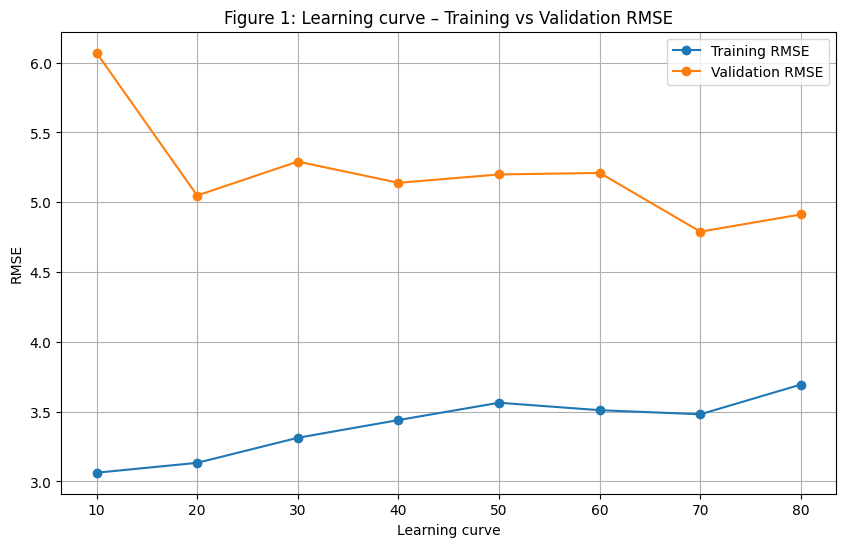

In [82]:
# Step 4: Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes * 100, train_rmse, label="Training RMSE", marker='o')
plt.plot(train_sizes * 100, val_rmse, label="Validation RMSE", marker='o')
plt.xlabel("Learning curve")
plt.ylabel("RMSE")
plt.title("Figure 1: Learning curve – Training vs Validation RMSE")
plt.legend()
plt.grid()
plt.savefig('Figure1_learning_curve_training-vs-validation-rmse.png', dpi=300)
plt.show()

### Learning curve analysis – Training vs. Validation RMSE

Figure 1 illustrates the evolution of the model's prediction error (RMSE) as a function of the percentage of training data used. For each training size (from 10% to 80%), a Decision Tree Regressor was trained, and RMSE was computed separately for:

- **Training set** → reflects how well the model fits the data it learned from.
- **Validation set** → reflects the model’s ability to generalize to unseen data.

---

#### Interpretation of the learning curve (Figure 1)

- The **Training RMSE** increases slightly with more data. This is expected: as the model sees more varied data, it can no longer perfectly fit small training subsets and must generalize more.
- The **Validation RMSE** initially decreases as training size increases, showing that the model benefits from additional data and generalizes better.
- From ~40% onward, **Validation RMSE plateaus**, indicating that additional training data brings diminishing improvements in generalization performance.

---

#### Underfitting zone

- When using only **10–20% of training data**, validation RMSE is high, and the gap between training and validation errors is large.
- This indicates **under-training**: the model has not seen enough data to capture meaningful patterns.

---

#### Why does RMSE Plateau?

- Beyond a certain amount of training data, the model has learned the core structure of the problem.
- As a result, **adding more data does not significantly reduce error**, unless:
  - Model capacity is increased (for example, deeper tree, more flexible model)
  - New, more informative features are introduced
  - Noise in the data is reduced

---

#### Conclusion

This learning curve confirms that the model benefits from more data up to a point. Around **50–60% of training data**, generalization stabilizes. Further performance gains would likely require model tuning or enhanced feature engineering rather than just more data.


[ENG]

EXERCISE 2 : CROSS-VALIDATION

[FR]

EXERCICE 2 : LA VALIDATION CROISEE

In [83]:
# Packages
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_regression

[ENG]

1. Recall the concept of cross-validation, and explain how the error is calculated, for example in a case of 10 blocks (10 folds)

[FR]

1. Rappelez le concept de la validation croisée, et précisez comment est calculée l’erreur, par exemple dans un cas de 10 blocs (10 fold)

### Cross-Validation in machine learning

Cross-validation is a technique used in machine learning to **evaluate the performance of a model on unseen data**. It involves dividing the available dataset into multiple **folds** or **subsets**. Each fold is used once as a **validation set**, while the model is trained on the remaining folds.

This process is repeated multiple times, with a **different fold** serving as the validation set in each iteration. Finally, the validation results from all iterations are **averaged** to provide a **more robust estimate** of the model’s performance.

#### Purpose of Cross-Validation

- The main goal is to **prevent overfitting**, which happens when a model performs very well on training data but poorly on new, unseen data.
- By evaluating the model on multiple validation sets, cross-validation offers a more **realistic estimate of the model’s generalization ability**—its performance on new, unseen data.

---

#### Evaluating the 10-Fold Cross-Validation error (K-Fold Cross Validation)

- The process begins by **randomly dividing the dataset into *K* folds**.
- The parameter **K** determines the number of subsets the data will be split into. A common choice for K is **between 5 and 10**, depending on dataset size.
    - Example: If K = 10, the dataset is divided into 10 equal parts.

#### Trade-offs:
- A **higher K** leads to a **less biased estimate**, but may increase **variance**, potentially leading to overfitting.
- A **lower K** resembles a simple **train-test split** and may provide a noisier estimate of performance.

---

#### K-Fold Cross-Validation procedure:

1. **Split** the dataset into K equal folds.
2. For each fold:
   - Use that fold as the **validation set**.
   - Use the remaining K−1 folds to **train** the model.
   - **Record** the validation score or error.
3. **Repeat** this process until every fold has served once as the validation set.
4. **Average** the recorded scores to obtain a **final performance metric** for the model.

This averaged result offers a **comprehensive and stable measure** of the model's performance.


[ENG]

2. Why use cross-validation? How does it differ from bootstrapping? How much does it cost to implement this approach? How can these approaches combat overtraining?

[FR]

2. Quel est l’intérêt de la validation croisée ? En quoi se distingue-t-elle du bootstraping ? Quel coût suppose la mise en oeuvre de cette approche ? En quoi ces approches permettent-elles de lutter contre surentraînement ?

### Purpose of Cross-Validation

Cross-validation provides a balance between robust evaluation and computational efficiency. It offers a good trade-off by dividing the data into *k* subsets (folds) for comprehensive model assessment. This technique helps evaluate a model's ability to generalize to unseen data.

---

#### What is Bootstrapping and how does Cross-Validation differ?

**Bootstrapping** is a resampling technique that involves repeatedly drawing samples from the dataset *with replacement* and estimating model performance on these samples. It is especially useful for estimating the uncertainty or variability of performance metrics.

**Cross-validation**, on the other hand, partitions the dataset into *k* folds and evaluates the model *k* times, each time training on *k-1* folds and validating on the remaining fold.

**Key differences:**
- Cross-validation is generally preferred for large, balanced datasets due to its lower variance.
- Bootstrapping is beneficial for small datasets and provides confidence intervals for metrics.

---

#### Computational cost of using Cross-Validation

Cross-validation requires training the model multiple times—once for each fold. For example, in **10-fold cross-validation**, the model is trained 10 times. This can be computationally expensive, particularly for:
- Large datasets
- Complex models
- Hyperparameter tuning
- Model comparison

It can also be time-consuming but provides more stable and reliable evaluation results.

---

#### How Cross-Validation and Bootstrapping help to limit overfitting

Both methods help ensure that the model generalizes well:

- **Encourage generalization**: They force the model to perform well on data it hasn't seen during training.
- **Highlight overfit models**: Inconsistent performance across folds (cross-validation) or samples (bootstrapping) often indicates overfitting.
- **Provide robust performance metrics**: Aggregating performance results across multiple splits or samples yields a more accurate estimate of the model's true effectiveness.


3. Rappelez l’intérêt que présente une forêt aléatoire par rapport à une approche classique du bagging. En particulier, comment sont choisies les variables à chaque split ? Quel est l’intérêtt sous-tendant ce choix ?

### What is Random Forest ?

Random Forest is a versatile machine learning algorithm that builds multiple decision trees during training and outputs either the **mode** (for classification) or the **mean** (for regression) of their predictions. It combines the concepts of Bagging (bootstrap aggregating) and random feature selection, which leads to improved accuracy and robustness.

---

#### What are Random Forest's advantages over Bagging?

The fundamental difference between Bagging and Random Forest is that Random Forest selects a random subset of features at each split, and the best feature from that subset is used to split the node. In contrast, Bagging considers **all** features when determining the best split at each node.

It's important to note that Random Forest is a type of bagging method. However, in addition to drawing random samples from the training set with replacement, it also draws random subsets of features when training individual trees. This added randomness makes the trees more independent of each other than in traditional Bagging, which often results in better predictive performance. 

It can also be computationally faster than Bagging, especially for datasets with many features.  
Overall, Random Forest introduces more randomness than Bagging and is therefore less prone to overfitting.

---

#### How does feature selection work in Random Forest?

Random Forest provides a built-in mechanism to evaluate the importance of features. The steps involved in feature selection are:

1. At each node, a subset of 𝑚 variables is randomly selected from the 𝑝 available variables.  
2. The best split is searched **only** among these 𝑚 selected variables.

Feature importance can be accessed using the `feature_importances_` attribute of a `RandomForestClassifier` or `RandomForestRegressor` object in Scikit-learn.

Feature importance in Random Forest can also be measured using a metric called **Gini importance**, which represents the total reduction in Gini impurity when a particular feature is used for splitting. A higher Gini importance indicates a more influential feature.

---

#### What is the purpose of this selection method?

- **Decorrelation of trees**: By limiting the choice of variables at each split, individual trees become less correlated. This helps reduce the model's dependency on a few strong predictors and lowers overall variance.

- **Improved robustness**: In classical Bagging, a few dominant variables may be chosen repeatedly across all trees, limiting the diversity of the ensemble. Randomizing feature selection enables the model to capture more patterns in the data.

- **Reduction of overfitting**: The added randomness during tree construction reduces the risk of overfitting to the bootstrap samples or noise in the dataset.

- **Efficiency with high-dimensional datasets**: When working with a large number of features, sub-sampling the variables at each split improves computational efficiency while maintaining high predictive performance.


[ENG]

4. For this exercise, use a random forest, this time with the following values (in Python): max depth=4, min samples leaf=0.26. In Python, this is RandomForestRegressor from sklearn.ensemble

[FR]

4. Utilisez pour cet exercice une forêt aléatoire, en prenant cette fois les valeurs suivantes (en Python) : max depth=4, min samples leaf=0.26. En Python, il s’agit de RandomForestRegressor à partir de sklearn.ensemble

In [84]:
# Generate regression data
X, y = make_regression(n_samples=1000, n_features=10, noise=0.2, random_state=8)

In [85]:
# Split the dataset into 80% train and 20% test
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.2, random_state= 8)

In [86]:
# Instantiate  Random Forest
rf= RandomForestRegressor(max_depth= 4, min_samples_leaf= 0.26, random_state= 8)

In [87]:
# 10 folds cross validation
scores = cross_val_score(rf, X, y, cv=10, scoring='neg_mean_squared_error')

[ENG]

5. Calculate the RMSE from the cross-validation, with a 10 fold. All this is done on the training dataset. This is the cross-val score function

[FR]

5. Calculez le RMSE issu de la validation croisée, avec un 10 fold. Tout ceci est effectué sur le jeu de données d’entraînement. Il s’agit ici de la fonction cross val score

In [88]:
# Calculate RMSE for each fold
rmse_scores = np.sqrt(-scores)

# Display results
print(f"RMSE par fold : {rmse_scores}")
print(f"RMSE moyen : {rmse_scores.mean():.2f}")
print(f"Écart-type du RMSE : {rmse_scores.std():.2f}")

RMSE par fold : [137.96697959 158.53064572 134.97532449 153.16059502 141.28817158
 158.31190072 122.3279516  161.40215438 131.56948918 137.12913162]
RMSE moyen : 143.67
Écart-type du RMSE : 12.64


### Cross-Validation evaluation – RMSE across folds

To assess the model’s stability and generalization performance, we computed the **Root Mean Squared Error (RMSE)** using **cross-validation**.

---

#### What was done:

- **K-fold cross-validation** was performed.
- For each fold, a score was returned as the **negative MSE** (default behavior in `scikit-learn` scoring).
- These scores were converted to **RMSE** by taking the square root of the negated values:
  
$$
\text{RMSE} = \sqrt{-\text{MSE}}
$$

---

#### Results:

- **RMSE per fold**:  
  $$
  [137.97,\ 158.53,\ 134.98,\ 153.16,\ 141.29,\ \dots]
  $$

- **Mean RMSE** = **143.67**  
  → On average, the model's predictions deviate from the true values by ~143.67 units across all folds.

- **Standard deviation of RMSE** = **12.64**  
  → This reflects the variability of performance across the different data splits.

---

#### Interpretation:

- A **low standard deviation** indicates consistent model performance across folds.
- If RMSE values vary widely between folds, the model may be sensitive to the training data or suffer from instability.

In this case, an RMSE of ~143.67 with a moderate standard deviation (12.64) suggests **reasonably consistent performance**, though further context (target scale, units, baseline) is needed to assess overall accuracy.


### Interpreting the standard deviation of RMSE in Cross-Validation

To evaluate the reliability of a model across different data splits, we examine not only the **mean RMSE** but also its **standard deviation**. This tells us how consistent the model's performance is during cross-validation.

---

#### Step 1: What does a standard deviation of 12.64 mean?

A standard deviation of **12.64** means that, across folds, the RMSE typically varies by ±12.64 units around the **mean RMSE** of **143.67**:

$$
143.67 \pm 12.64 \Rightarrow [131.03,\ 156.31]
$$

This indicates the range in which most of the RMSE scores fall.

---

#### Step 2: Is 12.64 a "low" or "high" deviation?

There’s no absolute threshold. Instead, we assess the deviation **relative to the scale of the errors or the target variable**. Here are two ways:

---

#### 1. **Relative Standard Deviation (RSD)**  
Also called the **coefficient of variation**, it measures variability relative to the mean:

$$
\text{RSD} = \frac{12.64}{143.67} \times 100 \approx 8.8\%
$$

- **RSD < 10%** → Low variability (stable performance)
- **RSD > 20%** → High variability (unstable performance)

With an RSD of **8.8%**, the model shows **stable predictive behavior across folds**.

---

#### 2. **Compare to Target Variable Scale**

- The standard deviation of the target (`mpg`) is **7.82**.
- The RMSE variation (**12.64**) is **larger than the target's own variability**.

This indicates that while the **mean prediction error is consistent**, the **spread of errors across folds** is still relatively large in relation to the variability of the actual target values. This suggests that the model may be sensitive to how training/validation sets are drawn.

> If the RMSE variation is small compared to the target variability, this suggests the model is **not overly sensitive** to how the training data is split — a desirable trait.

---

#### Conclusion

Although the RMSE scores vary moderately across folds, the **relative variation (RSD ≈ 8.8%)** is low. This reflects a **robust and repeatable model**, even though the absolute RMSE variability exceeds the standard deviation of the target. Further model tuning or data preprocessing might help narrow that gap.
